# 🚀 4강. 소리를 이미지로 바꾸는 멜스펙트로그램 (AI Pair) 🎨

> 📌 **이 노트북의 목표**
> - 오디오 파형(1차원)을 **멜스펙트로그램**(시간×주파수의 2차원 이미지)으로 바꿉니다.
> - "소리를 이미지로 본다"는 말이 실제로 무엇을 뜻하는지 코드로 확인합니다.
> - 이 이미지가 왜 CNN의 입력으로 자연스러운지 shape로 직접 확인합니다.

> 📍 **앞 노트북(1~3강)** 에서 파형·RMS·BPM·spectral centroid 같은 "숫자 몇 개"로 곡을 요약했습니다. 이번엔 곡 전체를 "숫자로 된 이미지 한 장"으로 통째로 바꿔봅니다 — 5강부터는 이 이미지(또는 이미지에서 뽑은 피처)로 장르를 분류합니다.

> 🧭 **이 강이 다루지 않는 것**
> - CNN이 이 이미지를 실제로 어떻게 학습하는지(합성곱·풀링의 구체적 동작) → **5강·8강**에서 RandomForest·ResNet-18로 직접 다룹니다.
> - STFT의 수학적 유도(푸리에 변환 자체) → 지금은 "짧은 창으로 잘라 주파수를 본다"는 직관만 잡고 넘어갑니다.
> - 지금은 "소리가 어떻게 숫자 이미지가 되는가"에 집중하세요.

> 📋 **오늘의 계약(contract)** — 이 다섯 줄이 맞으면 절반은 성공입니다
> 1. **입력**: 오디오 파일(mp3/wav) → `librosa.load`로 1차원 파형 `y` (float32, -1~1 근처)
> 2. **멜스펙트로그램 출력**: `(n_mels, time_frames)` — 예: `(128, 1292)` (128은 mel 주파수 bin 수, 1292는 시간 프레임 수)
> 3. **dB 변환 후 값 범위**: 대략 `[-80, 0]` dB (`power_to_db(..., ref=np.max)` 기준 — 최댓값이 0dB)
> 4. **CNN 입력 형태**: `(channel=1, n_mels, time_frames)` — 흑백 이미지 1장과 동일한 shape
> 5. **검증 한 줄**: `assert mel_db.shape[0] == 128`

In [1]:
# [패키지 확인] 처음 실행하는 환경이면 필요한 패키지를 조용히 설치합니다.
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "sklearn": "scikit-learn",
}

for module_name, package_name in required.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"[설치] {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
    else:
        print(f"[OK] {package_name}")

print("패키지 준비 완료")

[OK] numpy
[OK] pandas
[OK] matplotlib
[OK] librosa
[OK] soundfile
[OK] scikit-learn
패키지 준비 완료


> ⚠️ **본인 환경에 맞게 경로를 수정하세요**

바로 아래 `find_music_root()` 함수가 현재 작업 폴더(그리고 한두 단계 상위 폴더)에서 `Data` 폴더를 자동으로 찾습니다(수정할 절대경로 변수는 없습니다). 노트북과 `Data` 폴더를 같은 위치(또는 `Data`가 한두 단계 상위)에 두면 대부분 자동으로 인식됩니다. Colab에서 실행한다면 왼쪽 파일 탐색기에 `Data` 폴더를 업로드(또는 Google Drive 마운트)한 뒤 실행하면 됩니다.

In [2]:
# [환경 설정] 오디오 분석에 필요한 도구를 준비합니다.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

try:
    import librosa
    import librosa.display
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "librosa가 필요합니다. Colab/로컬에서 `pip install librosa soundfile` 후 다시 실행하세요."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)

# 한글 폰트 후보 중 실제로 설치된 것만 골라 씁니다 — plt.rcParams["font.family"] 대입은
# 존재하지 않는 폰트를 넣어도 예외를 던지지 않으므로, matplotlib이 인식한 설치 폰트
# 목록(fontManager.ttflist)에서 직접 존재 여부를 확인합니다.
import matplotlib.font_manager as fm
plt.rcParams["axes.unicode_minus"] = False
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_font_candidates = ["AppleGothic", "NanumGothic", "Malgun Gothic", "DejaVu Sans"]
_selected_font = next((f for f in _font_candidates if f in _installed_fonts), _font_candidates[-1])
plt.rcParams["font.family"] = _selected_font
print(f"[폰트] 선택된 한글 폰트: {_selected_font}")

SAMPLE_RATE = 22_050
AUDIO_EXTS = {".wav", ".mp3", ".flac", ".m4a", ".ogg"}

# 현재 폴더와 상위 폴더에서 Data/를 자동으로 찾습니다 — 노트북을 강의_AI_Pair/에서 열든
# 그 위 AI_Music/에서 열든 동작합니다. /content 경로는 Colab 표준 위치입니다.
def find_music_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd(),
        Path("/content/Music"),
        Path("/content"),
    ]
    for root in candidates:
        if (root / "Data").exists():
            return root
    return Path.cwd()


MUSIC_ROOT = find_music_root()
DATA_DIR = MUSIC_ROOT / "Data"
GENERATED_DIR = DATA_DIR / "generated_loops"
LATEST_DIR = DATA_DIR / "latest_music_local"
ATTENTION_FILE = DATA_DIR / "NewJeans-Attention.wav"

print(f"[경로] MUSIC_ROOT = {MUSIC_ROOT}")
print(f"[경로] DATA_DIR   = {DATA_DIR}")
print(f"[경로] LATEST_DIR = {LATEST_DIR}")

[경로] MUSIC_ROOT = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2
[경로] DATA_DIR   = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2/Data
[경로] LATEST_DIR = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2/Data/latest_music_local


> 💡 **읽고 넘어가도 되는 코드**: 아래 셀의 `collect_audio_files()`는 폴더 3곳을 순서대로 뒤지는 폴백(fallback) 탐색 로직이라, 이번 강의의 핵심 코드([Step 1], 아래쪽)보다 오히려 복잡합니다. 이 셀은 오디오 파일을 자동으로 찾아주는 준비 코드일 뿐이니 한 줄씩 따라가기보다는 읽고 넘어가도 됩니다.

In [3]:
# [데이터 찾기] 기본 샘플과 로컬 최신곡 샘플을 한 번에 모읍니다.
def collect_audio_files() -> list[Path]:
    files: list[Path] = []

    # 1순위: 사용자가 넣어둔 최신곡 로컬 샘플
    if LATEST_DIR.exists():
        files.extend(sorted(p for p in LATEST_DIR.iterdir() if p.suffix.lower() in AUDIO_EXTS))

    # 2순위: 공용 Attention 샘플
    if ATTENTION_FILE.exists():
        files.append(ATTENTION_FILE)

    # 3순위: 수업용 합성 루프
    if GENERATED_DIR.exists():
        files.extend(sorted(p for p in GENERATED_DIR.glob("*.wav") if p.is_file()))

    unique: list[Path] = []
    seen = set()
    for path in files:
        key = path.resolve()
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


audio_files = collect_audio_files()
if not audio_files:
    checked = [str(LATEST_DIR), str(ATTENTION_FILE), str(GENERATED_DIR)]
    raise FileNotFoundError(
        "분석할 오디오를 찾지 못했습니다. 확인한 경로:\n- " + "\n- ".join(checked)
    )

print(f"[발견] 분석 가능한 오디오 {len(audio_files)}개")
for i, path in enumerate(audio_files[:12], 1):
    print(f"  {i:02d}. {path.name}")
if len(audio_files) > 12:
    print(f"  ... 외 {len(audio_files) - 12}개")

[발견] 분석 가능한 오디오 13개
  01.  Your Shampoo Scent In The Flowers.mp3
  02. Grown Ups.mp3
  03. NewJeans-Attention.wav
  04. 사랑하게 될 거야.mp3
  05. 예뻤어 You Were Beautiful.mp3
  06. ambient_70bpm_soft_15s.wav
  07. ballad_80bpm_warm_15s.wav
  08. citypop_105bpm_glossy_15s.wav
  09. dance_120bpm_bright_15s.wav
  10. funk_110bpm_bouncy_15s.wav
  11. hiphop_95bpm_dark_15s.wav
  12. hyperpop_145bpm_sharp_15s.wav
  ... 외 1개


---
## 1. 📐 코드를 읽기 전에 — 멜스펙트로그램 개념

4강의 핵심은 **소리를 이미지처럼 바꾸는 것**입니다. 오디오 파일은 원래 시간에 따라 흔들리는 1차원 파형입니다. 하지만 딥러닝, 특히 CNN은 이미지처럼 생긴 2차원 패턴을 잘 다룹니다. 그래서 소리를 시간-주파수 이미지로 바꿔서 모델이 볼 수 있게 만듭니다.

### 파형과 스펙트로그램의 차이

| 표현 | 축 | 보여주는 것 | 한계 |
|---|---|---|---|
| Waveform | 시간 × 진폭 | 소리가 언제 커지고 작아지는지 | 어떤 주파수/악기가 있는지 보기 어려움 |
| Spectrogram | 시간 × 주파수 × 세기 | 어느 시간에 어떤 높이의 소리가 강한지 | 색상 해석이 처음에는 낯설 수 있음 |
| Mel Spectrogram | 시간 × mel 주파수 × 세기 | 사람이 듣는 방식에 가깝게 압축한 주파수 패턴 | 원래 소리의 모든 정보를 완벽히 보존하지는 않음 |

### STFT: 소리를 잘게 잘라 주파수를 보는 방법

음악은 시간이 지나며 계속 변합니다. 그래서 전체 곡을 한 번에 주파수 분석하지 않고, 짧은 창(window)으로 잘라가며 각 순간의 주파수 성분을 봅니다. 이 방법을 **STFT(Short-Time Fourier Transform)**라고 합니다.

- 짧은 창: 순간 변화에 민감하지만 주파수 구분이 거칠어짐
- 긴 창: 주파수 구분은 좋아지지만 순간 변화가 흐려짐
- `hop_length`: 다음 창으로 얼마나 이동할지 정하는 값

### Mel scale: 사람이 듣는 높이에 맞춘 축

사람은 낮은 주파수 차이는 민감하게 듣고, 높은 주파수 차이는 상대적으로 둔하게 듣습니다. mel scale은 이런 청각 특성을 반영해 주파수 축을 다시 배치합니다. 그래서 음악 장르 분류, 음성 인식, 오디오 태깅에서 자주 씁니다.

### dB 변환: 색이 잘 보이게 만드는 압축

오디오 에너지는 작은 값과 큰 값의 차이가 매우 큽니다. 그대로 그리면 큰 소리만 보이고 작은 패턴은 묻힙니다. `power_to_db`는 에너지를 dB 단위로 압축해서 조용한 악기와 배경 패턴도 색으로 볼 수 있게 합니다.

### CNN 입력으로 보면 무엇이 달라질까?

멜스펙트로그램은 이미지처럼 생각할 수 있습니다.

- 이미지 높이: mel 주파수 bin
- 이미지 너비: 시간 frame
- 픽셀 색상: 해당 시간/주파수의 에너지

5강 이후의 장르 분류에서는 이 이미지 패턴을 보고 모델이 "드럼이 반복되는 모양", "저음이 강한 구간", "고음역이 밝은 질감" 같은 단서를 학습하게 됩니다.

> ▶ **실행 전 예측** — 아래 [Step 1] 셀을 실행하기 전에 먼저 적어보세요.
> - 30초짜리 오디오라면 `mel_db.shape`의 두 숫자(주파수 bin, 시간 frame) 중 어느 쪽이 더 클까요?
> - `n_mels=128`로 고정했을 때, 곡 길이가 2배로 길어지면 `mel_db.shape`의 어느 축이 대략 2배로 늘어날까요?
> - dB로 변환한 값의 최댓값은 항상 정확히 0에 가까울까요, 곡마다 다를까요? (힌트: `ref=np.max`의 의미)

In [4]:
# [Step 1] 파형을 멜스펙트로그램 이미지로 바꾸는 함수를 준비합니다.
def load_audio(path: Path, duration: float = 30.0):
    return librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=duration)


def make_mel_db(y: np.ndarray, sr: int) -> np.ndarray:
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
    return librosa.power_to_db(mel, ref=np.max)

sample_path = audio_files[0]
y, sr = load_audio(sample_path)
mel_db = make_mel_db(y, sr)
print(f"[선택] {sample_path.name}")
print(f"waveform shape = {y.shape}")
print(f"mel spectrogram shape = {mel_db.shape}")

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[선택]  Your Shampoo Scent In The Flowers.mp3
waveform shape = (661500,)
mel spectrogram shape = (128, 1292)


### 결과 해석 — 예측과 비교

- `mel_db.shape`는 `(128, 시간프레임)` 형태로 나옵니다 — **주파수 축(128)은 `n_mels`로 고정**했기 때문에 곡 길이와 무관하게 항상 128이고, **시간 축만 곡 길이·`hop_length`에 비례**해 늘어납니다. "곡이 길어지면 이미지 세로가 아니라 가로가 길어진다"는 뜻입니다.
- `ref=np.max`는 "이 곡에서 가장 큰 에너지를 0dB로 놓고, 나머지를 상대적으로 얼마나 작은지"로 표현합니다 — 즉 dB의 최댓값은 항상 0 근처지만, **그 절대적인 크기(원래 에너지)는 곡마다 다릅니다.** 그래서 서로 다른 곡의 dB 값을 직접 비교할 때는 "이 곡 안에서 상대적으로 큰가/작은가"로 해석해야지, "이 곡이 저 곡보다 절대적으로 크다"로 해석하면 안 됩니다.

In [5]:
# [오디오 재생] 방금 만든 파형(y)을 직접 들어봅니다 — 아래 멜스펙트로그램과 같은 소리입니다.
# 청각(들리는 소리)과 시각(멜스펙트로그램의 색·패턴)을 직접 연결해서 확인하세요.
display(Audio(y, rate=sr))

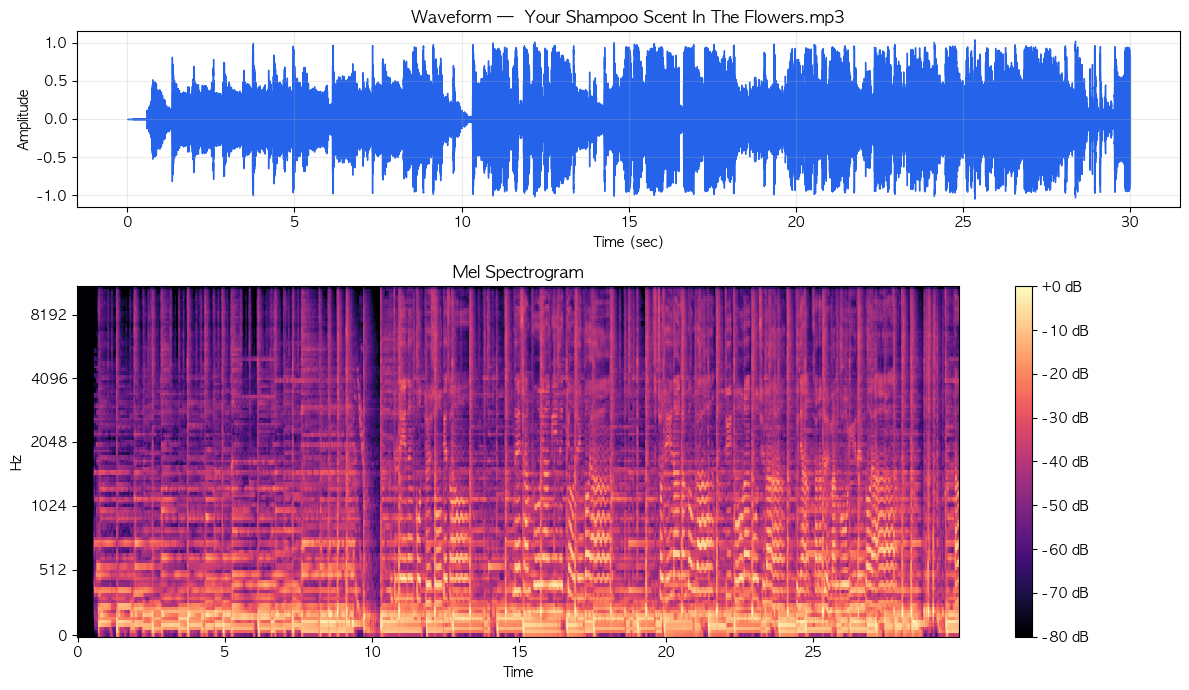

In [6]:
# [Step 2] 같은 소리를 파형과 멜스펙트로그램으로 나란히 봅니다.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [1, 2]})
librosa.display.waveshow(y, sr=sr, ax=axes[0], color="#2563eb")
axes[0].set_title(f"Waveform — {sample_path.name}")
axes[0].set_xlabel("Time (sec)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.25)

img = librosa.display.specshow(mel_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
axes[1].set_title("Mel Spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()

### 결과 해석 — 파형과 멜스펙트로그램, 같은 시간을 다르게 본다

- 위 파형 그래프에서 진폭이 10초 부근에서 살짝 잦아들었다가 다시 커지는 구간을 찾아보세요. 아래 멜스펙트로그램에서도 같은 x축(시간) 위치에 세로로 어두운 띠가 나타나는지 확인하세요 — 파형의 "조용한 순간"과 스펙트로그램의 "어두운 순간"은 같은 시간축 위에서 정확히 대응합니다. 두 표현이 같은 신호를 다른 방식으로 보여준다는 증거입니다.
- 이번엔 세로축(주파수)을 보세요. 에너지 대부분이 하단(0~2048Hz 부근)에 몰려 있고, 8192Hz 근처 최상단은 상대적으로 어둡습니다(옅은 보컬 배음 정도만 보임). 파형만 봐서는 "이 소리에 저음이 많은지 고음이 많은지"를 알 수 없지만, 멜스펙트로그램은 그걸 세로 위치로 바로 보여줍니다 — 이것이 CNN 입력으로 파형 대신 멜스펙트로그램을 쓰는 이유입니다.

### 🔍 확인해보기 — dB 변환이 정말 필요한가?

위 개념 설명에서 "dB 변환 없이 그대로 그리면 큰 소리만 보이고 작은 패턴은 묻힌다"고 했습니다. 말로만 들으면 안 와닿으니, 같은 멜스펙트로그램을 dB 변환 유무로 나란히 그려 직접 비교합니다.

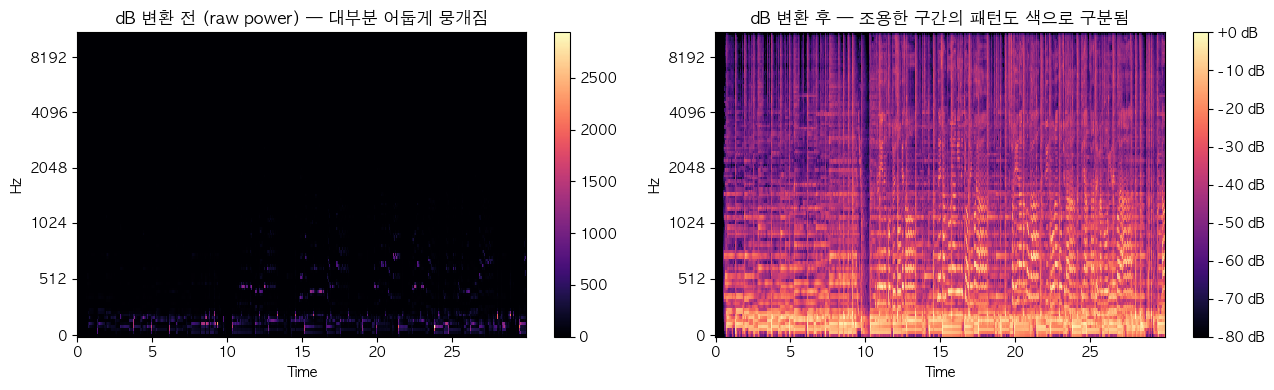

raw power 값 범위   : [0.000000, 2939.96]  (선형 스케일 — 큰 값과 작은 값의 차이가 극단적)
dB 변환 후 값 범위   : [-80.00, 0.00] dB  (로그 스케일 — 사람 눈에 훨씬 고르게 분포)


In [7]:
# [확인해보기] dB 변환 전(raw power) vs 변환 후(dB) — 같은 데이터, 다른 표현
mel_raw = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)  # power 스케일 그대로

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
img1 = librosa.display.specshow(mel_raw, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=axes[0], cmap="magma")
axes[0].set_title("dB 변환 전 (raw power) — 대부분 어둡게 뭉개짐")
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(mel_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
axes[1].set_title("dB 변환 후 — 조용한 구간의 패턴도 색으로 구분됨")
fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()

print(f"raw power 값 범위   : [{mel_raw.min():.6f}, {mel_raw.max():.2f}]  (선형 스케일 — 큰 값과 작은 값의 차이가 극단적)")
print(f"dB 변환 후 값 범위   : [{mel_db.min():.2f}, {mel_db.max():.2f}] dB  (로그 스케일 — 사람 눈에 훨씬 고르게 분포)")

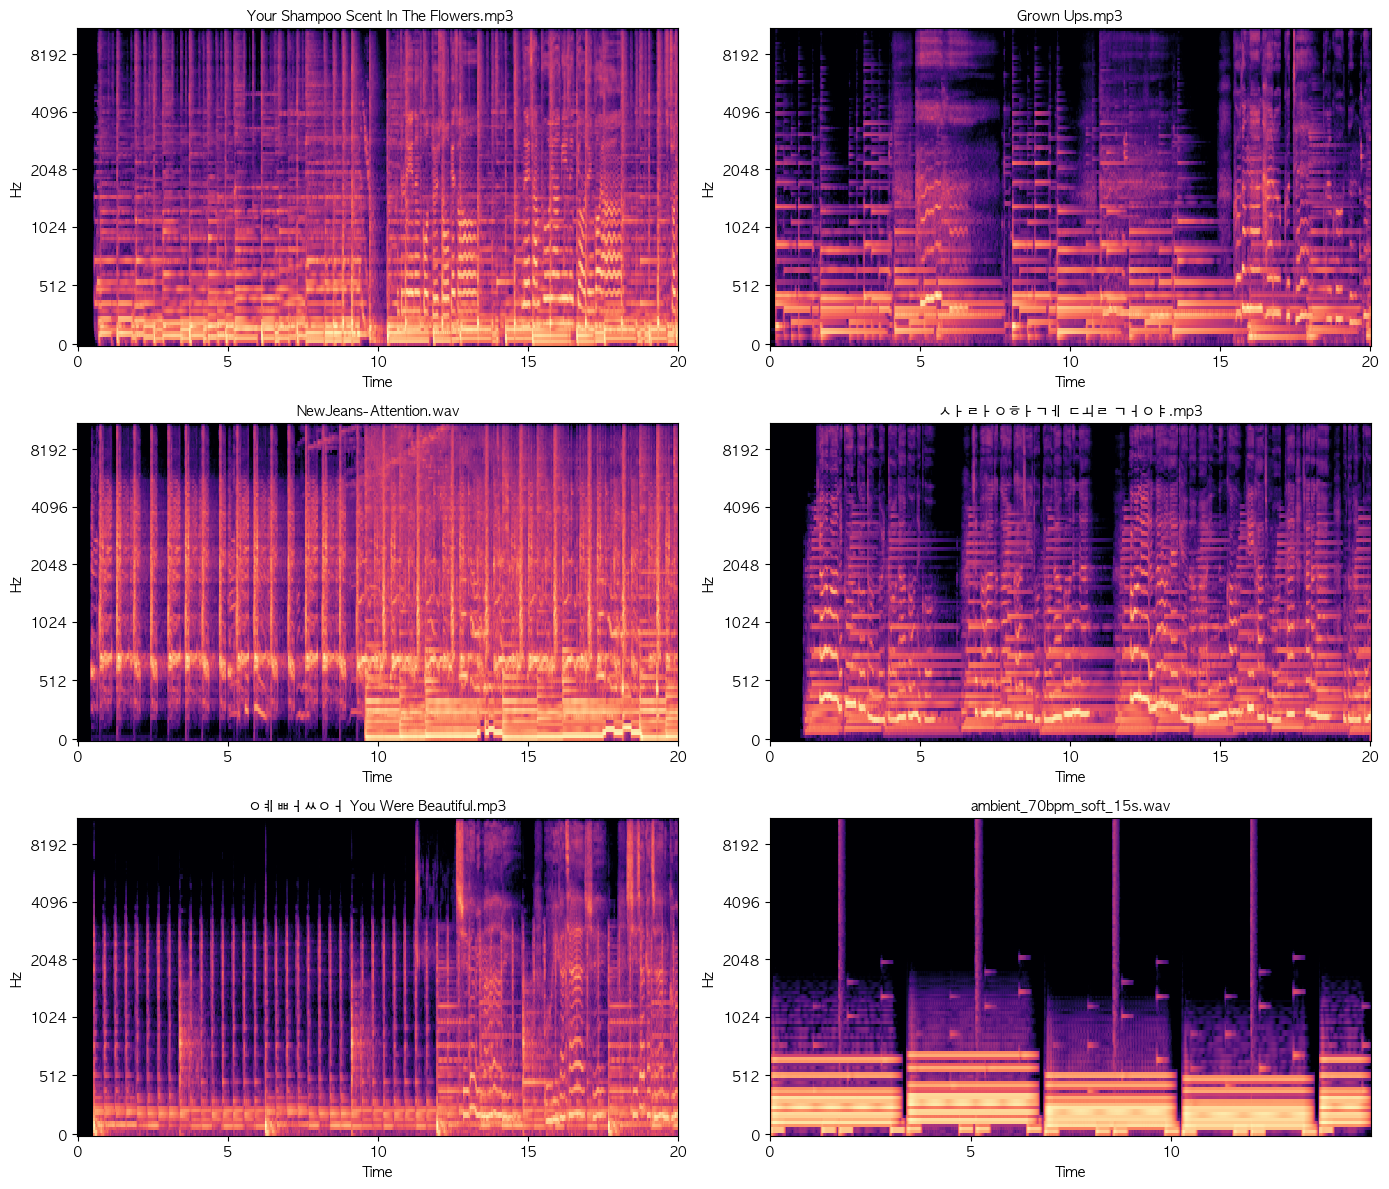

In [8]:
# [Step 3] 여러 곡을 멜스펙트로그램 카드로 비교합니다.
show_files = audio_files[:6]
cols = 2
rows = int(np.ceil(len(show_files) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, path in zip(axes, show_files):
    y_i, sr_i = load_audio(path, duration=20)
    mel_i = make_mel_db(y_i, sr_i)
    librosa.display.specshow(mel_i, sr=sr_i, hop_length=512, x_axis="time", y_axis="mel", ax=ax, cmap="magma")
    ax.set_title(path.name, fontsize=10)

for ax in axes[len(show_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 결과 해석 — 6곡의 멜스펙트로그램, 무엇이 다른가

- 위쪽 5곡(보컬이 있는 대중음악)은 8192Hz 근처까지 세로 줄무늬가 촘촘하고 규칙적으로 이어집니다 — 보컬의 자음·타악기 어택처럼 순간적으로 넓은 주파수 대역을 한꺼번에 채우는 소리가 많다는 뜻입니다.
- 오른쪽 아래 `ambient_70bpm_soft_15s.wav`는 다릅니다. 에너지가 거의 전부 2048Hz 아래에 머물고 그 위(4096·8192Hz)는 거의 새까맣습니다(-80dB에 가까움). 세로 줄무늬도 촘촘하지 않고 몇 초 간격으로 뚝뚝 끊어진 네모 블록처럼 보입니다 — 느리고(70bpm) 성긴 저음 소리만 반복된다는 뜻으로, 파일 이름의 "ambient·soft"와 그림이 그대로 일치합니다.
- `Grown Ups.mp3`는 5~8초 구간만 다른 곡들과 다르게 보입니다 — 촘촘한 세로 줄무늬 대신 저·중음(500~2000Hz) 위주의 뭉툭하고 연속적인 덩어리가 나타납니다. 같은 곡 안에서도 구간(보컬 구간 vs 간주 구간)에 따라 그림이 달라진다는 걸 보여주는 예시입니다.

→ 정리하면, **세로 위치(주파수 대역)**는 "저음/고음 어디에 에너지가 있는가", **가로 방향 줄무늬의 조밀함**은 "리듬이 얼마나 촘촘한가", **밝기(색)**는 "그 순간 에너지가 얼마나 강한가"를 보여줍니다. 이 세 가지가 장르·곡 구간을 구분할 때 실제로 보는 시각적 단서입니다.

> 🤖 **AI Agent에서 이렇게 씁니다**: 지금 한 일 — 원본 신호(오디오 파형)를 모델이 다루기 좋은 **숫자 표현(멜스펙트로그램)**으로 바꾸는 것 — 은 LLM의 토큰 임베딩과 근본적으로 같은 작업입니다. LLM도 사람이 쓰는 텍스트(문자열)를 그대로 계산하지 않고, 먼저 각 토큰을 수백~수천 차원의 숫자 벡터(임베딩)로 바꾼 뒤에야 신경망에 넣습니다. 오디오는 "시간×주파수" 2차원 표현으로, 텍스트는 "토큰×임베딩 차원" 2차원 표현으로 바뀐다는 점에서 구조가 같습니다 — 이런 변환을 통칭해 **표현 학습(representation learning)**이라 부르고, 이후 Phase2~3(LangGraph 에이전트)에서 오디오 피처와 텍스트 임베딩을 같은 파이프라인 안에서 다루게 되는 이유이기도 합니다.

In [9]:
# [Step 4] CNN 입력처럼 생각해봅니다.
# 흑백 이미지 1장이라면 shape는 (채널, 높이, 너비) = (1, mel_bins, frames)가 됩니다.
cnn_input = mel_db[np.newaxis, :, :]
print(f"mel_db.shape     = {mel_db.shape}")
print(f"cnn_input.shape  = {cnn_input.shape}")
print("해석: 1채널 이미지 1장을 CNN에 넣는다고 생각하면 됩니다.")

mel_db.shape     = (128, 1292)
cnn_input.shape  = (1, 128, 1292)
해석: 1채널 이미지 1장을 CNN에 넣는다고 생각하면 됩니다.


In [10]:
# [Step 5] 곡별 멜스펙트로그램의 평균 밝기를 비교합니다.
mel_rows = []
for path in audio_files:
    y_i, sr_i = load_audio(path, duration=20)
    mel_i = make_mel_db(y_i, sr_i)
    mel_rows.append({
        "file": path.name,
        "mel_mean_db": round(float(np.mean(mel_i)), 2),
        "mel_max_db": round(float(np.max(mel_i)), 2),
        "mel_min_db": round(float(np.min(mel_i)), 2),
    })

mel_df = pd.DataFrame(mel_rows).sort_values("mel_mean_db", ascending=False)
mel_df

,file,mel_mean_db,mel_max_db,mel_min_db
2,NewJeans-Attention.wav,-40.76,0.0,-80.0
0,Your Shampoo Scent In The Flowers.mp3,-44.92,0.0,-80.0
3,사랑하게 될 거야.mp3,-52.71,0.0,-80.0
4,예뻤어 You Were Beautiful.mp3,-55.07,0.0,-80.0
1,Grown Ups.mp3,-55.83,0.0,-80.0
11,hyperpop_145bpm_sharp_15s.wav,-60.40,0.0,-80.0
7,citypop_105bpm_glossy_15s.wav,-60.82,0.0,-80.0
6,ballad_80bpm_warm_15s.wav,-61.61,0.0,-80.0
8,dance_120bpm_bright_15s.wav,-62.00,0.0,-80.0
9,funk_110bpm_bouncy_15s.wav,-63.12,0.0,-80.0


> 🔍 **표를 보면 이상한 점이 있습니다** — `mel_max_db` 열은 13곡 전부 `0.0`, `mel_min_db` 열은 13곡 전부 `-80.0`으로 완전히 동일합니다. 버그가 아니라 `make_mel_db()`의 설계 때문입니다.
> - **`mel_max_db`가 항상 0.0인 이유**: `power_to_db(..., ref=np.max)`는 곡마다 **자기 자신의 최댓값**을 0dB 기준점으로 삼습니다. "이 곡에서 가장 큰 소리"는 정의상 항상 0dB이 됩니다 — 곡이 조용하든 시끄럽든 상관없이요.
> - **`mel_min_db`가 항상 -80.0인 이유**: `power_to_db`의 기본 옵션 `top_db=80`이 "0dB(최댓값) 기준으로 80dB보다 더 작은 값은 전부 -80dB로 잘라낸다"는 하한선입니다. 대부분의 곡에 무음에 가까운 구간이 있어 최솟값은 거의 항상 이 하한(-80.0)에 걸립니다.
> - 결과적으로 **`mel_max_db`·`mel_min_db` 두 열은 사실상 상수이고, 곡마다 실제로 다르게 나오는 값은 `mel_mean_db`뿐**입니다. 바로 아래 해석은 이 `mel_mean_db`에만 집중합니다.

### 결과 해석 — 곡별 밝기(mel_mean_db) 비교

위 표는 각 곡의 멜스펙트로그램 평균 dB 값을 큰 순서로 정렬한 것입니다. 평균 dB가 높을수록(0에 가까울수록) 그 곡은 조용한 구간 없이 에너지가 고르게·강하게 분포한다는 뜻이고, 낮을수록(음수가 클수록) 조용한 구간이 많거나 전반적으로 잔잔하다는 뜻입니다. 표를 직접 확인해 어떤 파일이 가장 위·아래에 있는지, 곡의 느낌과 실제로 맞아떨어지는지 비교해보세요.

> 🎲 **불확실성 참고**: 이 노트북은 `duration=20`으로 각 곡의 앞 20초만 잘라 분석합니다 — 후렴이 뒤에 있는 곡은 실제 "가장 강렬한 구간"의 에너지가 반영되지 않을 수 있습니다. 또한 `ref=np.max`가 곡마다 독립적으로 정규화되므로, 이 표의 dB 값은 절대적 크기 비교가 아니라 "각 곡 내부에서의 상대적 분포"로 해석해야 합니다.

### 5강으로 이어지는 다리

4강에서는 소리를 이미지처럼 보는 직관을 만들었습니다. 5강에서는 이 멜스펙트로그램과 오디오 피처를 이용해 장르 분류 모델을 만듭니다.

- 사람이 보는 것: 시간에 따라 달라지는 색과 패턴
- 모델이 보는 것: 숫자로 된 이미지 행렬
- 5강의 핵심: 이 패턴을 이용해 장르를 예측하기

---
## 🤝 AI Pair 섹션 — 멜스펙트로그램 직접 만들어보기

> **목표**: AI를 답 베끼는 도구가 아니라 *내 코드·판단을 검증해주는 동료*로 쓴다. (읽기용 — 실습 시간엔 핵심만 따라가도 됩니다)

| 단계 | 내가 하는 것 | AI가 하는 것 |
|---|---|---|
| 1️⃣ Solo | 먼저 직접 작성/판단 | (아직 X) |
| 2️⃣ Review | 내 코드·판단을 제출 | 리뷰 + 근거 설명 |
| 3️⃣ Debug | AI가 준 "조용히 틀린" 코드의 결함 찾기 | 의도적 버그 제공 |
| 4️⃣ Prompt Card | 실험 설계 프롬프트 익히기 | — |

### 1️⃣ Solo — 먼저 스스로 풀어보세요

### ✏️ [Solo 레벨 1] 직접 작성해 보세요 — n_mels를 128 → 64로 바꾸기

힌트: make_mel_db() 함수와 같은 로직으로 n_mels만 64로 바꿔서 mel_db_64 = ... 를 만들고
mel_db_64.shape가 어떻게 달라지는지 확인하세요. (주파수 축만 절반이 되는지 확인)

In [11]:
# TODO: 여기에 작성하세요

### ✏️ [Solo 레벨 2] 직접 작성해 보세요 — hop_length를 512 → 1024로 바꾸기

힌트: 레벨 1과 같은 방식이지만 이번엔 hop_length를 바꿉니다.
시간 축(frames) 개수가 대략 몇 배로 줄어드는지 먼저 예측하고 실행해서 확인하세요.

In [12]:
# TODO: 여기에 작성하세요

### 🔍 Solo 레벨 3 준비 — 리스트로 모은 결과를 그래프로 그리는 법

[Step 5]에서 이미 곡마다 결과를 `mel_rows` 리스트에 모아 `mel_df`라는 표로 만들었습니다. 표까지는 만들었지만, 그 표를 **그래프로** 그려본 적은 아직 없습니다. Solo 레벨 3은 n_mels 후보값마다 `mel_db.shape[0]`을 리스트에 모은 뒤 "그래프로 확인"해야 하는데, 지금까지 이 노트북에서 그린 그래프(`specshow`/`waveshow`)는 전부 스펙트로그램 **이미지**였지, "리스트에 쌓인 숫자 두 묶음을 선 그래프로 그리는 법"은 아직 쓴 적이 없습니다.

여기서는 그 방법만 미리 연습합니다 — 이미 갖고 있는 `mel_df`의 `mel_mean_db` 열을 선 그래프로 옮겨볼 뿐이니, 레벨 3에서 실제로 그릴 대상(n_mels vs `shape[0]`)과는 다른 데이터입니다.


### ✏️ [Solo 레벨 3 준비 — 확인해보기] 이미 만든 mel_df를 선 그래프로 그려봅니다.

리스트(또는 배열) 두 개(x, y)만 있으면 plt.plot(x, y, marker="o")로 바로 선 그래프가 됩니다.

In [ ]:
x_files = mel_df["file"].tolist()
y_values = mel_df["mel_mean_db"].tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(x_files)), y_values, marker="o", color="#2563eb")
ax.set_xticks(range(len(x_files)))
ax.set_xticklabels(x_files, rotation=75, ha="right", fontsize=8)
ax.set_ylabel("mel_mean_db")
ax.set_title("mel_df를 선 그래프로 — 이 패턴을 레벨 3의 (n_mels, shape[0])에도 적용하세요")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("[관찰] x축에 곡 이름, y축에 mel_mean_db를 넣어 이미 있는 표를 그래프로 옮겼을 뿐입니다.")
print("       레벨 3에서는 x축에 n_mels 후보값, y축에 그때의 shape[0]을 넣으면 같은 패턴이 됩니다.")


### ✏️ [Solo 레벨 3] 직접 작성해 보세요 — n_mels 자동 실험 + 그래프

힌트:
1) def run_nmels_experiment(n_mels_list): ... 함수를 만드세요.
2) 리스트 안 각 n_mels마다 멜스펙트로그램을 만들고 shape[0]을 기록하세요.
3) matplotlib으로 x=n_mels, y=shape[0] 그래프를 그려 선형 관계인지 확인하세요.

In [13]:
def run_nmels_experiment(n_mels_list):
    # TODO: 여기에 작성하세요
    pass

### 2️⃣ Review
아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.
```text
librosa로 멜스펙트로그램을 만드는 코드입니다: librosa.feature.melspectrogram(y, sr, n_mels=128, hop_length=512) 후 librosa.power_to_db(mel, ref=np.max).
1) n_mels를 128 → 64로 줄이면 CNN 입력 shape과 이미지의 시각적 해상도가 어떻게 달라지는지,
2) hop_length를 512 → 1024로 늘리면 시간 축 frame 수가 왜 절반 가까이 줄어드는지,
3) ref=np.max로 정규화한 dB 값을 서로 다른 두 곡 사이에서 직접 비교하면 안 되는 이유를
각각 근거를 들어 설명해줘.
```

> ℹ️ **이 셀은 선택(optional)입니다**

위 프롬프트를 ChatGPT/Claude 웹에 복사해 붙여넣는 것만으로 리뷰 실습은 충분합니다. 아래 코드 셀은 로컬 LLM 서버(LM Studio/Ollama)나 OpenRouter/OpenAI API 키가 이미 구성된 사람을 위한 것으로, 아무 설정 없이 실행하면 `Connection error`가 출력됩니다(노트북이 멈추는 에러가 아니라, `try/except`로 잡아 안내 문구만 보여주는 정상 동작입니다). 로컬/클라우드 LLM을 연결해 직접 리뷰를 받아보고 싶다면 `PROVIDER` 값만 바꿔서 실행해 보세요.

In [14]:
# ── 2️⃣ Review (코드형, 선택 실습) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio(00-1)/Ollama(00-2) 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
try:
    from openai import OpenAI
except ImportError:
    OpenAI = None

if OpenAI is None:
    print("[안내] openai 패키지가 없어 이 Review 셀을 건너뜁니다 — `!pip install openai` 후 다시 실행하세요(선택 사항입니다).")
else:
    PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
    PROVIDERS = {
        "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
        "ollama":     {"base_url": "http://localhost:11434/v1", "model": "llama3.2",              "api_key": "ollama"},
        "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "openai/gpt-4o-mini", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
        "openai":     {"base_url": "https://api.openai.com/v1",  "model": "gpt-4o-mini",          "api_key": os.getenv("OPENAI_API_KEY", "")},
    }
    cfg = PROVIDERS[PROVIDER]
    client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"])

    review_prompt = (
        "librosa로 멜스펙트로그램을 만드는 코드입니다: "
        "librosa.feature.melspectrogram(y, sr, n_mels=128, hop_length=512) 후 librosa.power_to_db(mel, ref=np.max). "
        "1) n_mels를 128 -> 64로 줄이면 CNN 입력 shape과 시각적 해상도가 어떻게 달라지는지, "
        "2) hop_length를 512 -> 1024로 늘리면 시간 축 frame 수가 왜 절반 가까이 줄어드는지, "
        "3) ref=np.max로 정규화한 dB 값을 서로 다른 두 곡 사이에서 직접 비교하면 안 되는 이유를 각각 설명해줘."
    )

    try:
        resp = client.chat.completions.create(
            model=cfg["model"],
            messages=[{"role": "user", "content": review_prompt}],
        )
        print(resp.choices[0].message.content)
    except Exception as exc:
        print(f"[안내] {PROVIDER} 서버 연결 실패 — 로컬 서버 실행 여부 또는 API 키를 확인하세요: {exc}")

[안내] lmstudio 서버 연결 실패 — 로컬 서버 실행 여부 또는 API 키를 확인하세요: Connection error.


### 3️⃣ Debug — "조용히 틀린" 코드 찾기
아래는 **실행은 되고 에러도 안 나지만, 조용히 잘못된 그림을 보여주는** 코드입니다. 결함을 찾아 고치세요.

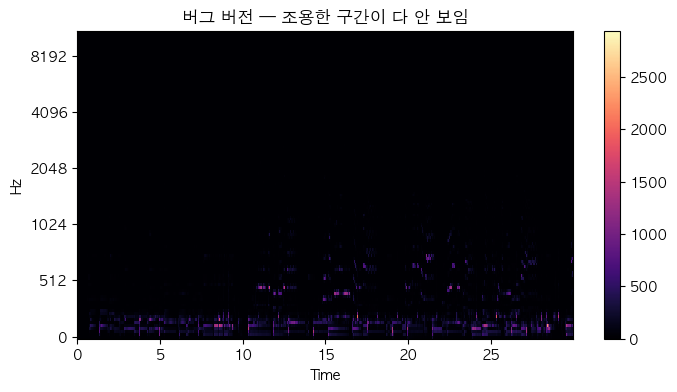

In [15]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 조용히 잘못된 정보를 보여줍니다. 결함을 찾아 고쳐보세요.
mel_bug = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
# ⚠️ 여기를 의심해보세요 — dB 변환을 생략했습니다.

fig, ax = plt.subplots(figsize=(8, 4))
img = librosa.display.specshow(mel_bug, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=ax, cmap="magma")
ax.set_title("버그 버전 — 조용한 구간이 다 안 보임")
fig.colorbar(img, ax=ax)
plt.show()

💭 **생각해 볼 점**:
- 이 코드는 에러 없이 잘 "실행"됩니다. 왜 에러가 안 날까요? (`specshow`는 어떤 스케일의 배열이든 색으로 그려주기 때문입니다 — 값이 선형이든 로그든 상관하지 않습니다.)
- 그런데 왜 결과가 "조용히 틀렸다"고 할 수 있을까요? (선형 power 값은 큰 에너지와 작은 에너지의 차이가 지수적으로 커서, 색상 맵이 대부분 어두운 쪽에 몰려 조용한 구간의 패턴이 안 보입니다.)
- 위 셀을 정상 버전(dB 변환 포함, [Step 2] 셀)과 비교해서 어떤 부분에서 색상 분포가 달라지는지 직접 확인해 보세요.

### 4️⃣ Prompt Card
📝 **카드 1~3** (이 단원 최적화, 실험 설계형):
```text
1. "n_mels를 32, 64, 128, 256으로 바꿔가며 멜스펙트로그램을 그리고, 어느 지점부터 시각적으로 더 이상 정보가 늘어나지 않는지(수확체감) AI와 같이 예측한 뒤 실행해서 확인해줘."
2. "hop_length를 256, 512, 1024로 바꾸면 같은 30초 곡의 mel_db.shape가 어떻게 달라지는지 공식으로 먼저 계산해보고, 실제 실행 결과와 맞는지 AI에게 검증받아줘."
3. "fmax(최대 주파수)를 8000으로 제한하는 것과 제한하지 않는 것의 차이를 AI와 같이 예측하고, 보컬 위주 K-pop 곡에서 실제로 차이가 나는지 확인해줘."
```
🎯 **마무리 체크**: [ ] Solo 직접 [ ] Review 실행검증 [ ] Debug 결함 찾음 [ ] Prompt Card 1개 내 노트에 정리

---
## 📚 [세션 요약] 소리를 이미지로 바꾸는 멜스펙트로그램

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: STFT로 짧은 구간별 주파수를 구하고, mel scale로 사람의 청각에 맞게 압축한 뒤, dB로 변환해 조용한 패턴까지 보이게 만드는 것이 멜스펙트로그램의 전체 과정이다.
> 2. **실무적 활용**: 오디오를 "시간×주파수 이미지"로 바꾸면, 이미지 분류에 쓰던 CNN 도구를 오디오 분류에도 그대로 쓸 수 있다 — 이것이 5강·8강에서 할 일이다.
>
> ➡️ **다음 단계**: `5강_멜스펙트로그램_장르분류(AI_Pair).ipynb` — 지금 만든 멜스펙트로그램과 오디오 피처로 RandomForest 장르 분류 모델을 만듭니다.